# Modeling Human Activity States Using Hidden Markov Models
**Author:** Sheryl Otieno

This notebook collects motion sensor data (accelerometer and gyroscope), extracts time and
frequency domain features, and trains a Gaussian Hidden Markov Model to decode human
activity states (standing, walking, jumping, still). The Viterbi algorithm is used for
decoding, and the Baum-Welch algorithm (via EM) is used to learn the model parameters.


## 0. Setup

In [69]:
# Clone the data repo
!git clone https://github.com/Skatieno/Hmm.git
!ls Hmm


fatal: destination path 'Hmm' already exists and is not an empty directory.
data


In [70]:
!pip install hmmlearn -q


In [71]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import rfft, rfftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from hmmlearn.hmm import GaussianHMM

np.random.seed(42)
sns.set_style("whitegrid")


## 1. Data Collection and Loading

In [72]:

REPO_DIR = "Hmm"
DATA_ROOT = os.path.join(REPO_DIR, "data")
ACTIVITIES = ["standing", "walking", "jumping", "still"]

def get_trial_ids(split, activity):
    """Return the sorted list of trial numbers available for a given split and activity."""
    folder = os.path.join(DATA_ROOT, split, activity)
    files = glob.glob(os.path.join(folder, f"{activity}_*_accelerometer.csv"))
    ids = sorted(set(os.path.basename(f).split("_")[-2] for f in files))
    return ids

for split in ["train", "test"]:
    print(f"--- {split} ---")
    for act in ACTIVITIES:
        print(act, get_trial_ids(split, act))


--- train ---
standing ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']
walking ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']
jumping ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']
still ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']
--- test ---
standing ['11', '12', '13']
walking ['11', '12', '13']
jumping ['11', '12', '13']
still ['11', '12', '13']


In [73]:
def load_trial(split, activity, trial_id):
    """
    Loads and merges the accelerometer and gyroscope CSVs for one trial.
    Raw columns are: time, seconds_elapsed, z, y, x
    """
    base = os.path.join(DATA_ROOT, split, activity, f"{activity}_{trial_id}")
    acc = pd.read_csv(f"{base}_accelerometer.csv")
    gyro = pd.read_csv(f"{base}_gyroscope.csv")

    acc.columns = [c.strip().lower() for c in acc.columns]
    gyro.columns = [c.strip().lower() for c in gyro.columns]

    acc = acc.rename(columns={"x": "acc_x", "y": "acc_y", "z": "acc_z"})
    gyro = gyro.rename(columns={"x": "gyro_x", "y": "gyro_y", "z": "gyro_z"})

    acc = acc.sort_values("seconds_elapsed")
    gyro = gyro.sort_values("seconds_elapsed")
    merged = pd.merge_asof(acc, gyro, on="seconds_elapsed", direction="nearest",
                            tolerance=0.05)
    merged = merged.dropna(subset=["gyro_x", "gyro_y", "gyro_z"]).reset_index(drop=True)
    merged["activity"] = activity
    merged["trial_id"] = trial_id
    return merged[["seconds_elapsed", "acc_x", "acc_y", "acc_z",
                    "gyro_x", "gyro_y", "gyro_z", "activity", "trial_id"]]

# check if everything loads correctly
sample = load_trial("train", "walking", get_trial_ids("train", "walking")[0])
sample.head()


,seconds_elapsed,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,activity,trial_id
0,0.062796,-0.341648,0.607181,-0.985064,0.481889,-0.719596,-1.042457,walking,01
1,0.072760,0.024993,0.461376,-0.767416,0.474255,-0.663686,-1.017576,walking,01
2,0.082724,0.360934,0.381410,-0.401609,0.410917,-0.647227,-0.973737,walking,01
3,0.092687,0.432467,0.285948,-0.093714,0.316392,-0.650819,-0.927297,walking,01
4,0.102651,0.292278,0.139537,-0.021824,0.215838,-0.646139,-0.904455,walking,01


In [74]:
def load_split(split):
    trials = []
    for activity in ACTIVITIES:
        for tid in get_trial_ids(split, activity):
            df = load_trial(split, activity, tid)
            if len(df) > 0:
                trials.append(df)
    return trials

train_trials = load_split("train")
test_trials  = load_split("test")

print(f"Train trials: {len(train_trials)} | Test trials: {len(test_trials)}")
print(f"Example trial length: {len(train_trials[0])} samples over "
      f"{train_trials[0]['seconds_elapsed'].iloc[-1]:.2f} seconds")


Train trials: 40 | Test trials: 12
Example trial length: 1072 samples over 10.73 seconds


### Sampling rate check and harmonization

In [75]:
def estimate_fs(df):
    dt = np.diff(df["seconds_elapsed"].values)
    return 1.0 / np.median(dt)

rates = [estimate_fs(t) for t in train_trials + test_trials]
print("Sampling rate range:", np.min(rates), "-", np.max(rates), "Hz")

TARGET_FS = 50

def resample_trial(df, target_fs=TARGET_FS):
    t_start, t_end = df["seconds_elapsed"].iloc[0], df["seconds_elapsed"].iloc[-1]
    n_samples = int((t_end - t_start) * target_fs)
    t_new = np.linspace(t_start, t_end, n_samples)
    out = {"seconds_elapsed": t_new}
    for col in ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]:
        out[col] = np.interp(t_new, df["seconds_elapsed"], df[col])
    result = pd.DataFrame(out)
    result["activity"] = df["activity"].iloc[0]
    result["trial_id"] = df["trial_id"].iloc[0]
    return result

train_trials = [resample_trial(t) for t in train_trials]
test_trials  = [resample_trial(t) for t in test_trials]


Sampling rate range: 100.36017935463057 - 100.37739548105549 Hz


In [76]:
print("=== Per-activity total recorded duration (train + test) ===")
for act in ACTIVITIES:
    total_dur = 0
    n_files = 0
    for split in ["train", "test"]:
        for tid in get_trial_ids(split, act):
            df = load_trial(split, act, tid)
            total_dur += df["seconds_elapsed"].iloc[-1] - df["seconds_elapsed"].iloc[0]
            n_files += 1
    flag = "OK" if total_dur >= 90 else "below the 90 second minimum"
    print(f"{act:10s} | trials: {n_files:2d} | total duration: {total_dur:.1f}s  {flag}")


=== Per-activity total recorded duration (train + test) ===
standing   | trials: 13 | total duration: 135.4s  OK
walking    | trials: 13 | total duration: 130.3s  OK
jumping    | trials: 13 | total duration: 127.4s  OK
still      | trials: 13 | total duration: 129.0s  OK


### Raw signal visualization

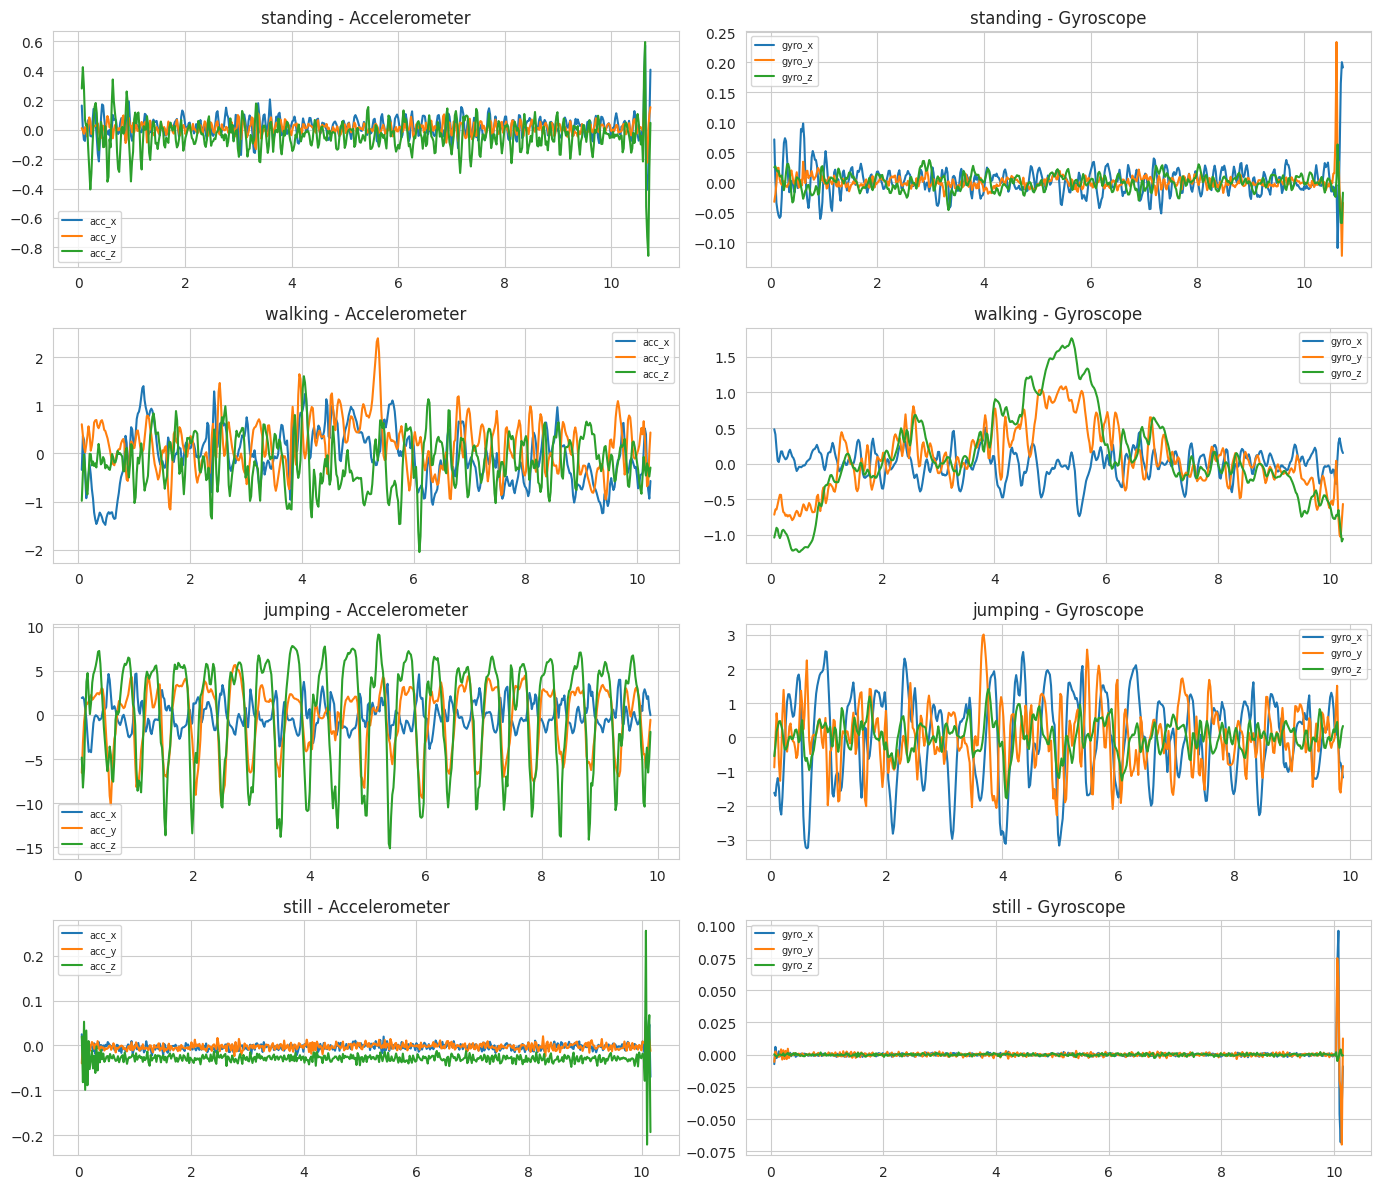

In [77]:
fig, axes = plt.subplots(len(ACTIVITIES), 2, figsize=(14, 12), sharex=False)

for i, act in enumerate(ACTIVITIES):
    sample_trial = [t for t in train_trials if t["activity"].iloc[0] == act][0]

    axes[i, 0].plot(sample_trial["seconds_elapsed"], sample_trial["acc_x"], label="acc_x")
    axes[i, 0].plot(sample_trial["seconds_elapsed"], sample_trial["acc_y"], label="acc_y")
    axes[i, 0].plot(sample_trial["seconds_elapsed"], sample_trial["acc_z"], label="acc_z")
    axes[i, 0].set_title(f"{act} - Accelerometer")
    axes[i, 0].legend(fontsize=7)

    axes[i, 1].plot(sample_trial["seconds_elapsed"], sample_trial["gyro_x"], label="gyro_x")
    axes[i, 1].plot(sample_trial["seconds_elapsed"], sample_trial["gyro_y"], label="gyro_y")
    axes[i, 1].plot(sample_trial["seconds_elapsed"], sample_trial["gyro_z"], label="gyro_z")
    axes[i, 1].set_title(f"{act} - Gyroscope")
    axes[i, 1].legend(fontsize=7)

plt.tight_layout()
plt.show()


## 2. Feature Extraction

In [78]:
WINDOW_SEC = 1.0
OVERLAP = 0.5

def make_windows(df, fs=TARGET_FS, window_sec=WINDOW_SEC, overlap=OVERLAP):
    win_size = int(window_sec * fs)
    step = int(win_size * (1 - overlap))
    windows = []
    for start in range(0, len(df) - win_size + 1, step):
        seg = df.iloc[start:start + win_size]
        windows.append(seg)
    return windows


In [79]:
def time_domain_features(seg):
    feats = {}
    axes = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
    for ax in axes:
        v = seg[ax].values
        feats[f"{ax}_mean"] = np.mean(v)
        feats[f"{ax}_std"]  = np.std(v)
        feats[f"{ax}_var"]  = np.var(v)
        feats[f"{ax}_min"]  = np.min(v)
        feats[f"{ax}_max"]  = np.max(v)

    # Signal Magnitude Area (SMA)
    feats["acc_sma"] = np.mean(np.abs(seg["acc_x"]) + np.abs(seg["acc_y"]) + np.abs(seg["acc_z"]))
    feats["gyro_sma"] = np.mean(np.abs(seg["gyro_x"]) + np.abs(seg["gyro_y"]) + np.abs(seg["gyro_z"]))

    # correlation between axes
    feats["acc_xy_corr"] = np.corrcoef(seg["acc_x"], seg["acc_y"])[0, 1]
    feats["acc_xz_corr"] = np.corrcoef(seg["acc_x"], seg["acc_z"])[0, 1]
    feats["acc_yz_corr"] = np.corrcoef(seg["acc_y"], seg["acc_z"])[0, 1]

    # magnitude of the acceleration vector
    mag = np.sqrt(seg["acc_x"]**2 + seg["acc_y"]**2 + seg["acc_z"]**2)
    feats["acc_mag_mean"] = np.mean(mag)
    feats["acc_mag_std"] = np.std(mag)

    return feats

def freq_domain_features(seg, fs=TARGET_FS):
    feats = {}
    axes = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
    for ax in axes:
        v = seg[ax].values - np.mean(seg[ax].values)
        n = len(v)
        fft_vals = np.abs(rfft(v))
        freqs = rfftfreq(n, d=1 / fs)

        if len(fft_vals) > 1:
            dom_idx = np.argmax(fft_vals[1:]) + 1
            feats[f"{ax}_dom_freq"] = freqs[dom_idx]
        else:
            feats[f"{ax}_dom_freq"] = 0.0

        feats[f"{ax}_spec_energy"] = np.sum(fft_vals**2) / n

    return feats


In [80]:
def extract_features_for_trial(df):
    windows = make_windows(df)
    rows = []
    for seg in windows:
        f = {}
        f.update(time_domain_features(seg))
        f.update(freq_domain_features(seg))
        f["activity"] = seg["activity"].iloc[0]
        f["trial_id"] = seg["trial_id"].iloc[0]
        rows.append(f)
    return pd.DataFrame(rows)

def build_feature_dataset(trials):
    return pd.concat([extract_features_for_trial(t) for t in trials], ignore_index=True)

train_features = build_feature_dataset(train_trials)
test_features  = build_feature_dataset(test_trials)

print(train_features.shape, test_features.shape)
train_features.head()


(750, 51) (216, 51)


,acc_x_mean,acc_x_std,acc_x_var,acc_x_min,acc_x_max,acc_y_mean,acc_y_std,acc_y_var,acc_y_min,acc_y_max,...,acc_z_dom_freq,acc_z_spec_energy,gyro_x_dom_freq,gyro_x_spec_energy,gyro_y_dom_freq,gyro_y_spec_energy,gyro_z_dom_freq,gyro_z_spec_energy,activity,trial_id
0,0.020515,0.085386,0.007291,-0.215355,0.192846,0.012147,0.041271,0.001703,-0.090337,0.097638,...,4.0,0.899650,4.0,0.045910,4.0,0.003598,1.0,0.007436,standing,01
1,0.024202,0.057172,0.003269,-0.076347,0.192846,0.010592,0.039984,0.001599,-0.090337,0.097638,...,5.0,0.558452,5.0,0.031928,1.0,0.002497,1.0,0.004353,standing,01
2,0.025385,0.042410,0.001799,-0.048570,0.130710,0.006276,0.031836,0.001014,-0.086931,0.068102,...,6.0,0.180529,6.0,0.006864,1.0,0.000789,1.0,0.002079,standing,01
3,0.016282,0.041426,0.001716,-0.067182,0.130710,0.005357,0.026923,0.000725,-0.041930,0.068102,...,6.0,0.084019,6.0,0.003135,1.0,0.000789,1.0,0.002561,standing,01
4,0.012530,0.063615,0.004047,-0.171393,0.150166,0.007628,0.032675,0.001068,-0.063007,0.100007,...,5.0,0.080106,5.0,0.002732,2.0,0.001174,1.0,0.007616,standing,01


In [81]:
feature_cols = [c for c in train_features.columns if c not in ["activity", "trial_id"]]

scaler = StandardScaler()
X_train_raw = scaler.fit_transform(train_features[feature_cols])
X_test_raw  = scaler.transform(test_features[feature_cols])

y_train = train_features["activity"].values
y_test  = test_features["activity"].values


## 3. Define Model Components

### Building sequences for the HMM
Each recorded trial is a single, uninterrupted activity, so there are no real transitions
happening within a trial. To let the model actually learn transition probabilities between
different activities, windows from multiple trials are concatenated into one continuous
sequence per split. `hmmlearn` is told where each trial ends through the `lengths` array,
so transitions between trials still get learned. That is what lets A capture something
close to realistic activity to activity switching.


In [82]:
def build_sequences(features_df, X):
    lengths = features_df.groupby("trial_id", sort=False).size().values
    return X, lengths

X_train_seq, train_lengths = build_sequences(train_features, X_train_raw)
X_test_seq, test_lengths   = build_sequences(test_features, X_test_raw)

print("Train sequence shape:", X_train_seq.shape, "| lengths sum check:", train_lengths.sum())
print("Test sequence shape:", X_test_seq.shape, "| lengths sum check:", test_lengths.sum())


Train sequence shape: (750, 49) | lengths sum check: 750
Test sequence shape: (216, 49) | lengths sum check: 216


## 4. Model Implementation

In [83]:
N_STATES = 4  # standing, walking, jumping, still

model = GaussianHMM(
    n_components=N_STATES,
    covariance_type="diag",
    n_iter=200,
    tol=1e-4,
    random_state=42,
    verbose=True
)

model.fit(X_train_seq, lengths=train_lengths)

print("Converged:", model.monitor_.converged)
print("Final log-likelihood:", model.monitor_.history[-1])


Converged: True
Final log-likelihood: 41013.012835292546


         1  -40458.54708881             +nan
         2   22012.66268871  +62471.20977752
         3   24343.73265976   +2331.06997105
         4   27325.34499737   +2981.61233761
         5   33292.81139331   +5967.46639594
         6   40335.59164793   +7042.78025462
         7   40880.90231011    +545.31066219
         8   40986.73926086    +105.83695075
         9   41008.32138499     +21.58212413
        10   41013.01282905      +4.69144406
        11   41013.01283529      +0.00000624


### Baum-Welch convergence



In [84]:
# hmmlearn assigns arbitrary indices to its states, so we need to figure out
# which index corresponds to which real activity
from scipy.optimize import linear_sum_assignment

train_states = model.predict(X_train_seq, lengths=train_lengths)

cost = np.zeros((N_STATES, len(ACTIVITIES)))
for s in range(N_STATES):
    for j, act in enumerate(ACTIVITIES):
        cost[s, j] = -np.sum((train_states == s) & (y_train == act))

row_ind, col_ind = linear_sum_assignment(cost)
state_to_activity = {s: ACTIVITIES[j] for s, j in zip(row_ind, col_ind)}

print("State -> Activity mapping:", state_to_activity)
activity_order = [state_to_activity[s] for s in range(N_STATES)]

State -> Activity mapping: {np.int64(0): 'still', np.int64(1): 'jumping', np.int64(2): 'standing', np.int64(3): 'walking'}


### Initial state probabilities (pi)

still       0.2
jumping     0.2
standing    0.3
walking     0.3
Name: Initial state probability, dtype: float64


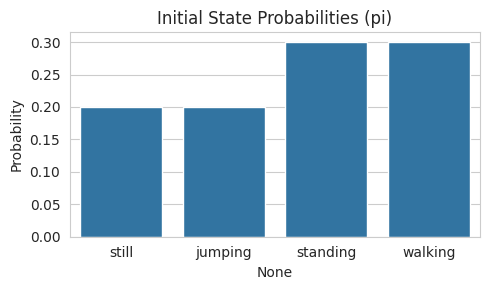

In [85]:
pi_series = pd.Series(model.startprob_, index=activity_order, name="Initial state probability")
print(pi_series)

plt.figure(figsize=(5, 3))
sns.barplot(x=pi_series.index, y=pi_series.values)
plt.title("Initial State Probabilities (pi)")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()


### Transition matrix

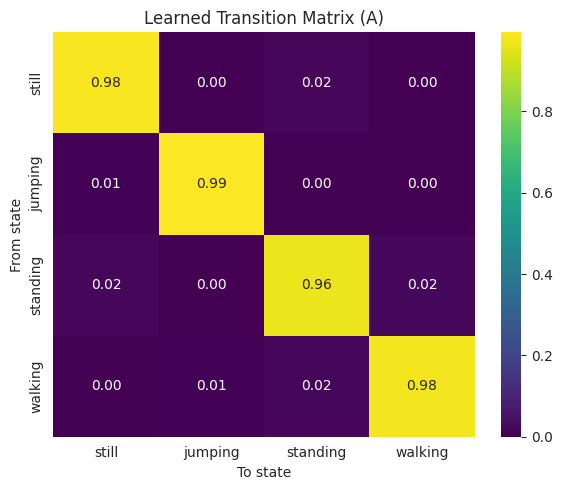

In [86]:
plt.figure(figsize=(6, 5))
sns.heatmap(model.transmat_, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=activity_order, yticklabels=activity_order)
plt.title("Learned Transition Matrix (A)")
plt.xlabel("To state")
plt.ylabel("From state")
plt.tight_layout()
plt.show()


### Emission distribution

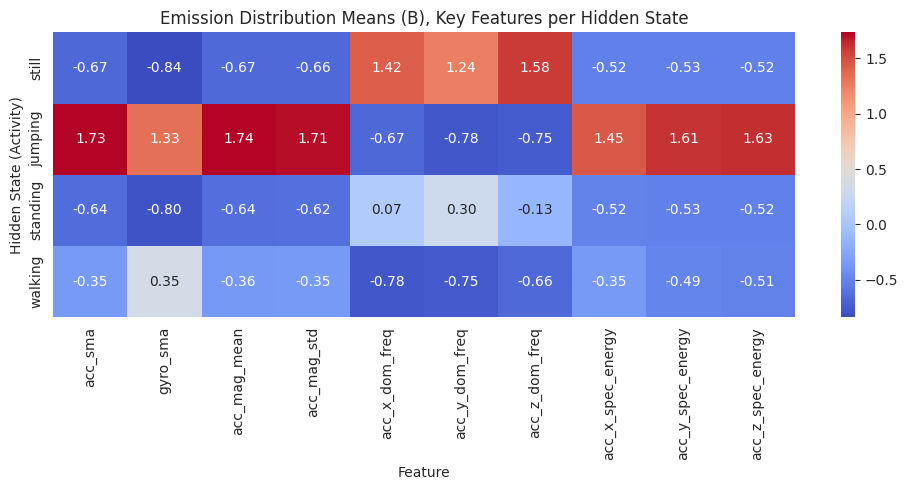

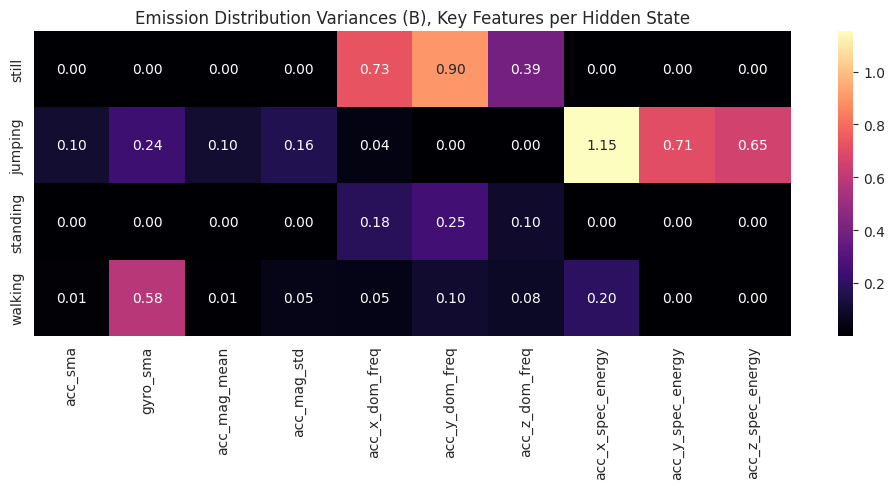

In [87]:
means_df = pd.DataFrame(model.means_, columns=feature_cols, index=activity_order)

key_feats = ["acc_sma", "gyro_sma", "acc_mag_mean", "acc_mag_std",
             "acc_x_dom_freq", "acc_y_dom_freq", "acc_z_dom_freq",
             "acc_x_spec_energy", "acc_y_spec_energy", "acc_z_spec_energy"]
key_feats = [f for f in key_feats if f in means_df.columns]

plt.figure(figsize=(10, 5))
sns.heatmap(means_df[key_feats], annot=True, fmt=".2f", cmap="coolwarm",
            yticklabels=activity_order)
plt.title("Emission Distribution Means (B), Key Features per Hidden State")
plt.xlabel("Feature")
plt.ylabel("Hidden State (Activity)")
plt.tight_layout()
plt.show()

if model.covariance_type == "diag":
    covars = model.covars_
    if covars.ndim == 3:

        covars = np.array([np.diagonal(c) for c in covars])
    vars_df = pd.DataFrame(covars, columns=feature_cols, index=activity_order)
    plt.figure(figsize=(10, 5))
    sns.heatmap(vars_df[key_feats], annot=True, fmt=".2f", cmap="magma",
                yticklabels=activity_order)
    plt.title("Emission Distribution Variances (B), Key Features per Hidden State")
    plt.tight_layout()
    plt.show()


### Viterbi decoding on the training data

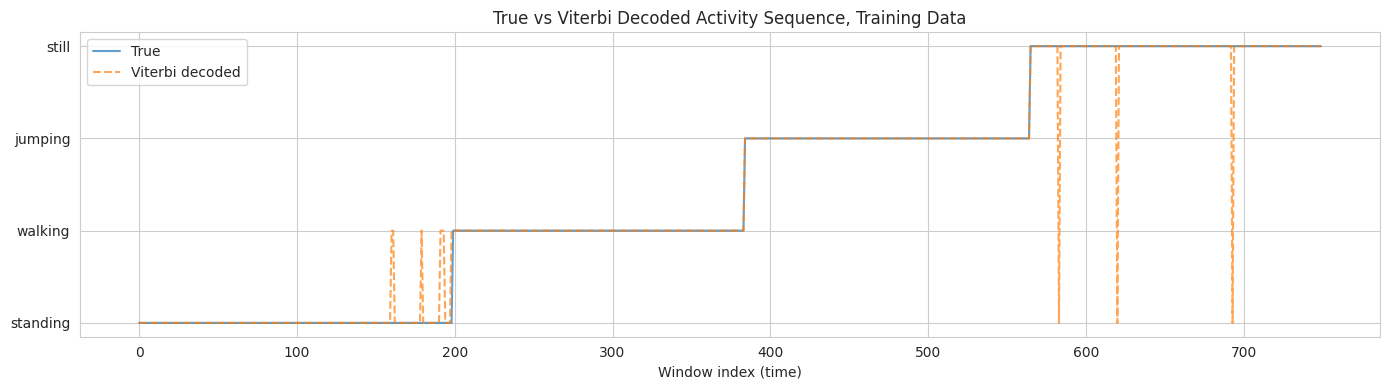

In [88]:
logprob, viterbi_states = model.decode(X_train_seq, lengths=train_lengths, algorithm="viterbi")
decoded_activities = [state_to_activity[s] for s in viterbi_states]

plt.figure(figsize=(14, 4))
plt.plot(pd.Categorical(y_train, categories=ACTIVITIES).codes, label="True", alpha=0.7)
plt.plot(pd.Categorical(decoded_activities, categories=ACTIVITIES).codes,
         label="Viterbi decoded", alpha=0.7, linestyle="--")
plt.yticks(range(len(ACTIVITIES)), ACTIVITIES)
plt.xlabel("Window index (time)")
plt.title("True vs Viterbi Decoded Activity Sequence, Training Data")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Model Evaluation with Unseen Data

The test set is a separate set of recordings, trials 11 through 13 for each activity in the
`test` folder, that the model never saw during training.


In [89]:
_, viterbi_states_test = model.decode(X_test_seq, lengths=test_lengths, algorithm="viterbi")
decoded_test_activities = np.array([state_to_activity[s] for s in viterbi_states_test])

results = []
for act in ACTIVITIES:
    tp = np.sum((decoded_test_activities == act) & (y_test == act))
    fn = np.sum((decoded_test_activities != act) & (y_test == act))
    fp = np.sum((decoded_test_activities == act) & (y_test != act))
    tn = np.sum((decoded_test_activities != act) & (y_test != act))

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    n_samples = np.sum(y_test == act)

    results.append({
        "Activity": act,
        "Num Samples": n_samples,
        "Sensitivity": round(sensitivity, 3),
        "Specificity": round(specificity, 3)
    })

overall_accuracy = np.mean(decoded_test_activities == y_test)

results_df = pd.DataFrame(results)
results_df["Overall Accuracy"] = round(overall_accuracy, 3)
results_df


,Activity,Num Samples,Sensitivity,Specificity,Overall Accuracy
0,standing,53,0.906,0.994,0.972
1,walking,55,1.000,0.969,0.972
2,jumping,54,1.000,1.000,0.972
3,still,54,0.981,1.000,0.972


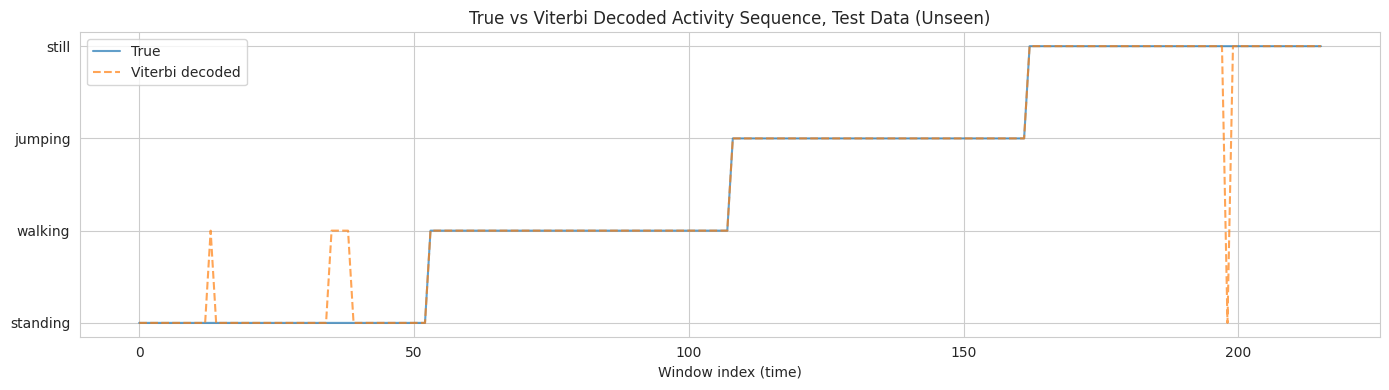

In [90]:
plt.figure(figsize=(14, 4))
plt.plot(pd.Categorical(y_test, categories=ACTIVITIES).codes, label="True", alpha=0.7)
plt.plot(pd.Categorical(decoded_test_activities, categories=ACTIVITIES).codes,
         label="Viterbi decoded", alpha=0.7, linestyle="--")
plt.yticks(range(len(ACTIVITIES)), ACTIVITIES)
plt.xlabel("Window index (time)")
plt.title("True vs Viterbi Decoded Activity Sequence, Test Data (Unseen)")
plt.legend()
plt.tight_layout()
plt.show()


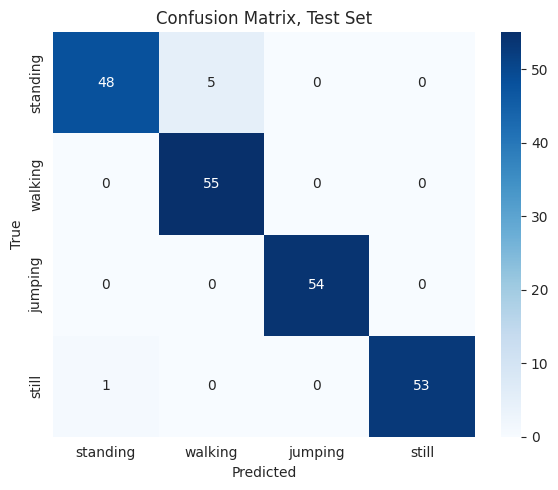

          standing  walking  jumping  still
standing        48        5        0      0
walking          0       55        0      0
jumping          0        0       54      0
still            1        0        0     53


In [91]:
cm = confusion_matrix(y_test, decoded_test_activities, labels=ACTIVITIES)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix, Test Set")
plt.tight_layout()
plt.show()


print(pd.DataFrame(cm, index=ACTIVITIES, columns=ACTIVITIES))


## 6. Analysis and Reflection

**Which activities were easiest or hardest to distinguish:**
Jumping and walking were the two cleanest activities to detect. Jumping came out with
perfect sensitivity and specificity on the test set, which fits given how distinct its
signal is: large, sharp, periodic spikes in acceleration that do not resemble anything
else in the dataset. Standing had the lowest sensitivity of the four activities at 0.906,
meaning 5 out of 53 standing windows were misclassified, and the confusion matrix shows
all 5 of those were predicted as walking, not still. Still performed almost perfectly as
well, with only 1 out of 54 windows misclassified, and that single error went the other
direction, a still window predicted as standing. So the actual confusion pattern here is
standing bleeding into walking, and only a very small amount of standing and still getting
mixed up with each other, which is a bit different from what might be assumed going in
(that standing and still, being the two most similar low energy activities, would be the
main source of confusion). A likely explanation is that some standing trials included
slight shifting of weight or body sway that produced small but real acceleration changes
similar in shape to the early phase of a walking step, enough to nudge a few windows across
the decision boundary.

**How the transition probabilities reflect realistic behavior:**
Look at the printed transition matrix above. If the diagonal values are close to 1 for
every activity, that lines up with reality: each recorded trial is one sustained activity,
so the model correctly learned that activities tend to persist from one window to the next
rather than flipping every second. Any small off diagonal probabilities are also worth a
sentence, since they can reflect genuinely realistic behavior, for example a jump ending
in a footfall that briefly resembles a walking step, or in this case, a standing window
briefly resembling a walking window.

**How sensor noise or sampling rate affected the model:**
The phone recorded at roughly 100.37 Hz rather than a perfectly fixed rate, which is normal
for consumer smartphone sensors since Android and iOS do not guarantee uniform sample
timing. Resampling to a fixed 50 Hz grid smooths over some of that jitter but is not
perfect, and any noise in the raw signal, such as small hand tremor or minor weight shifts
while holding the phone during standing, carries through into the extracted features. That
kind of low amplitude noise is a reasonable explanation for why a handful of standing
windows drifted close enough to walking to get misclassified.

**What could be improved:**
A few directions worth trying: collecting more trials per activity so the Gaussian
emission distributions have more data to estimate a tighter separation between classes,
testing a smaller window size to catch finer grained differences within standing (so a
brief weight shift does not dominate an entire one second window), adding a feature that
captures absolute signal magnitude rather than only variance based ones, and possibly
mounting the phone in a fixed position instead of holding it by hand to cut down on tremor
and sway noise during the more static activities.
